In [1]:
import os, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix

# ── Config (all settings in one place) ─────────────────────────
TRAIN_DIR   = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Train'
TEST_DIR    = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Test'
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
SEED        = 42

# Training schedule
PHASE1_EPOCHS = 5    # head only  (~5 min)
PHASE2_EPOCHS = 20   # full model (~45 min)
PHASE1_LR     = 1e-3
PHASE2_LR     = 8e-5

# Mixup
MIXUP_ALPHA = 0.4

# ── Reproducibility ─────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = True   # faster convolutions on GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

Device : cpu
GPU    : CPU only


Classes      : 200
Train images : 9414  (~47/class)
Test  images : 2374   (~11/class)


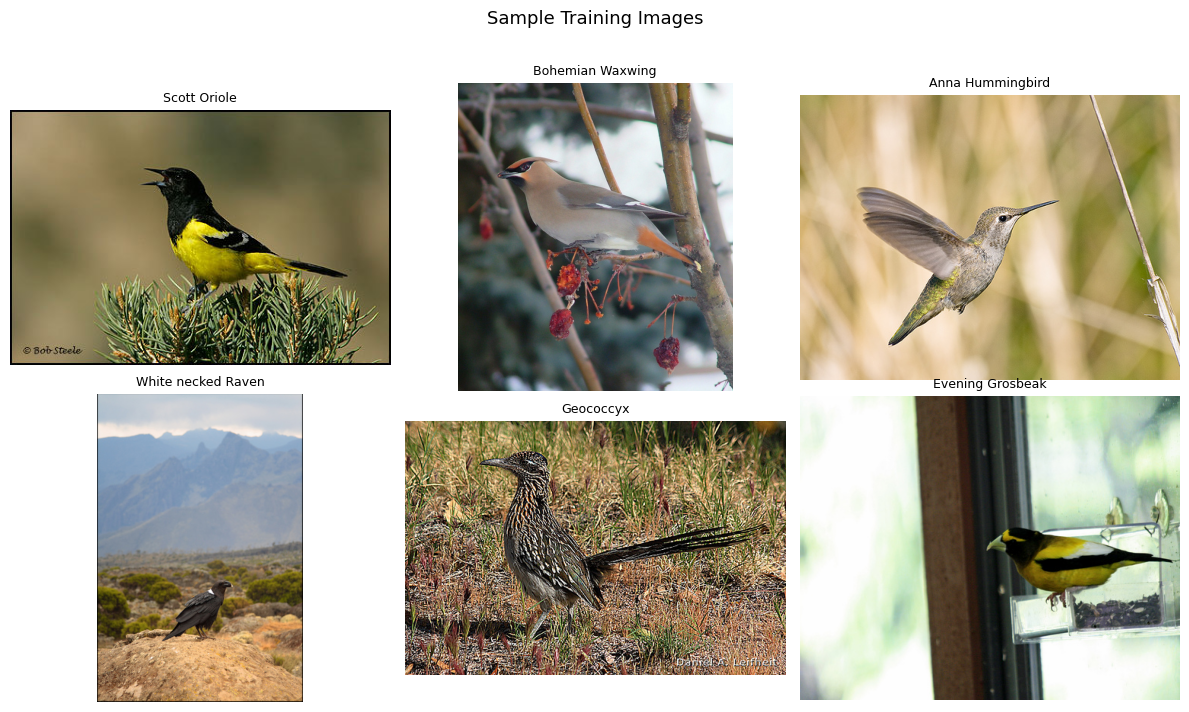

In [2]:
train_classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES   = len(train_classes)

train_total = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes)
test_total  = sum(len(os.listdir(os.path.join(TEST_DIR,  c))) for c in train_classes)

print(f"Classes      : {NUM_CLASSES}")
print(f"Train images : {train_total}  (~{train_total//NUM_CLASSES}/class)")
print(f"Test  images : {test_total}   (~{test_total//NUM_CLASSES}/class)")

# Show 6 sample birds
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, cls in zip(axes.flatten(), random.sample(train_classes, 6)):
    folder = os.path.join(TRAIN_DIR, cls)
    img = Image.open(os.path.join(folder, random.choice(os.listdir(folder)))).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' '), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [3]:
# ── Strong training augmentation ────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))  # hides patches → forces global features
])

# ── Clean eval transform ─────────────────────────────────────────
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Datasets ─────────────────────────────────────────────────────
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_data  = datasets.ImageFolder(TEST_DIR,  transform=val_transforms)
CLASS_NAMES = full_train.classes

# 80/20 train-val split (fixed seed)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_data, val_data = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Val uses clean transforms (no augmentation)
val_dataset = datasets.ImageFolder(TRAIN_DIR, transform=val_transforms)
val_data    = torch.utils.data.Subset(val_dataset, val_data.indices)

# ── Loaders ───────────────────────────────────────────────────────
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({train_size} images)")
print(f"Val   batches : {len(val_loader)}  ({val_size} images)")
print(f"Test  batches : {len(test_loader)}  ({len(test_data)} images)")

Train batches : 236  (7532 images)
Val   batches : 59  (1882 images)
Test  batches : 75  (2374 images)


In [4]:
def build_model(num_classes, freeze_backbone=True):
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Stronger custom head with BatchNorm
    in_features = model.classifier[1].in_features   # 1536 for B3
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable:,} / {total:,} params")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 299MB/s]


Trainable : 893,640 / 11,589,872 params


In [5]:
# ── Mixup ────────────────────────────────────────────────────────
def mixup_batch(imgs, labels, alpha=MIXUP_ALPHA):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(imgs.size(0)).to(device)
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


# ── One training epoch (with Mixup) ─────────────────────────────
def train_epoch(model, loader, criterion, optimizer, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            imgs, y_a, y_b, lam = mixup_batch(imgs, labels)
            preds = model(imgs)
            loss  = mixup_loss(criterion, preds, y_a, y_b, lam)
            correct += (lam * (preds.argmax(1) == y_a).float()
                      + (1 - lam) * (preds.argmax(1) == y_b).float()).sum().item()
        else:
            preds = model(imgs)
            loss  = criterion(preds, labels)
            correct += (preds.argmax(1) == labels).sum().item()

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

    return total_loss / total, correct / total


# ── One eval epoch (no Mixup) ────────────────────────────────────
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss  = criterion(preds, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

In [6]:
criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer    = optim.Adam(model.classifier.parameters(), lr=PHASE1_LR)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None

print("=" * 65)
print("PHASE 1 — Classifier head only")
print("=" * 65)

for epoch in range(PHASE1_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, use_mixup=False)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:2d}/{PHASE1_EPOCHS} | "
          f"Train {tr_acc*100:.2f}% | Val {vl_acc*100:.2f}% | "
          f"Loss {vl_loss:.4f} | {time.time()-t0:.0f}s")

print(f"\nBest after Phase 1: {best_val_acc*100:.2f}%")

PHASE 1 — Classifier head only


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch  1/5 | Train 10.22% | Val 29.86% | Loss 3.3417 | 894s
Epoch  2/5 | Train 25.36% | Val 37.35% | Loss 3.0061 | 839s
Epoch  3/5 | Train 32.09% | Val 41.34% | Loss 2.8270 | 849s
Epoch  4/5 | Train 35.40% | Val 44.42% | Loss 2.7444 | 892s
Epoch  5/5 | Train 38.34% | Val 45.59% | Loss 2.7139 | 836s

Best after Phase 1: 45.59%


In [7]:
# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-7  # warm restart at epoch 10
)

print("=" * 65)
print("PHASE 2 — Full fine-tune + Mixup")
print("=" * 65)

for epoch in range(PHASE2_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, use_mixup=True)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        flag = "  ✅ new best"

    print(f"Epoch {epoch+1:2d}/{PHASE2_EPOCHS} | "
          f"Train {tr_acc*100:.2f}% | Val {vl_acc*100:.2f}% | "
          f"Loss {vl_loss:.4f} | {time.time()-t0:.0f}s{flag}")

# Load best checkpoint
model.load_state_dict(best_weights)
print(f"\n🎯 Best Val Accuracy: {best_val_acc*100:.2f}%")

PHASE 2 — Full fine-tune + Mixup
Epoch  1/20 | Train 35.69% | Val 58.29% | Loss 2.3188 | 1438s  ✅ new best
Epoch  2/20 | Train 41.34% | Val 61.64% | Loss 2.1929 | 1510s  ✅ new best
Epoch  3/20 | Train 45.61% | Val 64.72% | Loss 2.1204 | 1489s  ✅ new best
Epoch  4/20 | Train 48.57% | Val 67.27% | Loss 2.0540 | 1496s  ✅ new best
Epoch  5/20 | Train 51.63% | Val 68.23% | Loss 2.0002 | 1507s  ✅ new best
Epoch  6/20 | Train 52.92% | Val 68.97% | Loss 1.9749 | 1495s  ✅ new best
Epoch  7/20 | Train 53.67% | Val 69.45% | Loss 1.9594 | 1528s  ✅ new best
Epoch  8/20 | Train 53.62% | Val 70.09% | Loss 1.9351 | 1526s  ✅ new best
Epoch  9/20 | Train 54.13% | Val 70.35% | Loss 1.9306 | 1562s  ✅ new best
Epoch 10/20 | Train 56.34% | Val 69.71% | Loss 1.9421 | 1562s
Epoch 11/20 | Train 56.41% | Val 71.63% | Loss 1.8879 | 1586s  ✅ new best
Epoch 12/20 | Train 57.23% | Val 72.74% | Loss 1.8559 | 1587s  ✅ new best
Epoch 13/20 | Train 59.39% | Val 74.07% | Loss 1.8377 | 1596s  ✅ new best
Epoch 14/20 | Tra

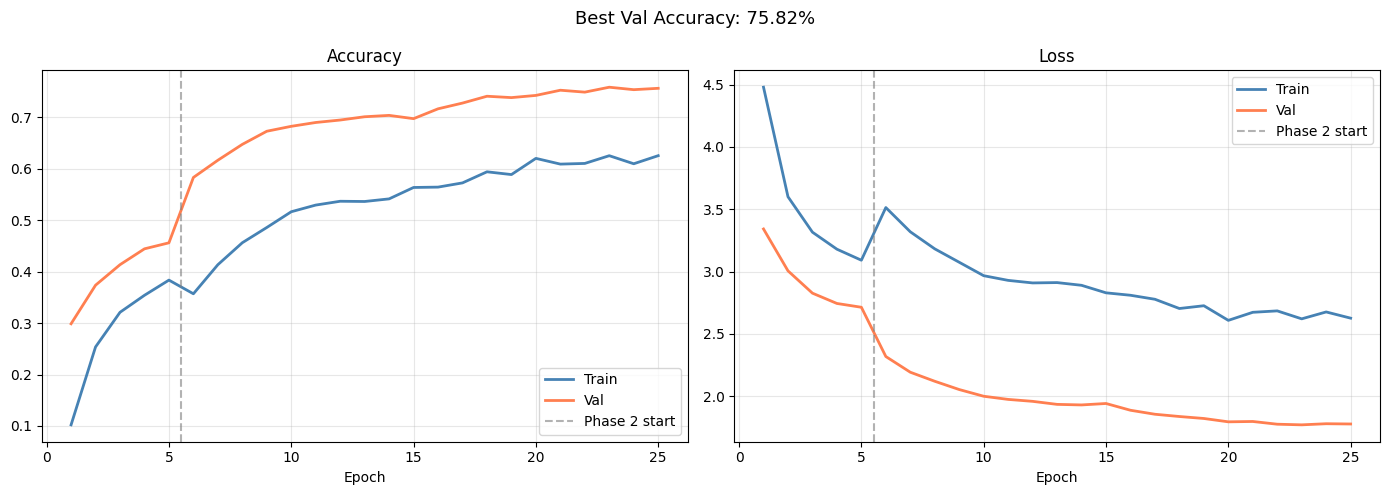

In [8]:
total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
ep = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
split = PHASE1_EPOCHS + 0.5

for ax, metric, title in [
    (ax1, ('train_acc', 'val_acc'), 'Accuracy'),
    (ax2, ('train_loss', 'val_loss'), 'Loss')
]:
    ax.plot(ep, history[metric[0]], label='Train', color='steelblue', linewidth=2)
    ax.plot(ep, history[metric[1]], label='Val',   color='coral',     linewidth=2)
    ax.axvline(split, color='gray', linestyle='--', alpha=0.6, label='Phase 2 start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Best Val Accuracy: {best_val_acc*100:.2f}%', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"🎯 Final Test Accuracy : {test_acc*100:.2f}%")

# Top-5 accuracy
def top5_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, top5 = model(imgs).topk(5, dim=1)
            correct += top5.eq(labels.view(-1,1).expand_as(top5)).any(dim=1).sum().item()
            total   += labels.size(0)
    return correct / total

print(f"🎯 Top-5 Test Accuracy : {top5_acc(model, test_loader)*100:.2f}%")

🎯 Final Test Accuracy : 75.61%
🎯 Top-5 Test Accuracy : 94.36%


Model saved ✅


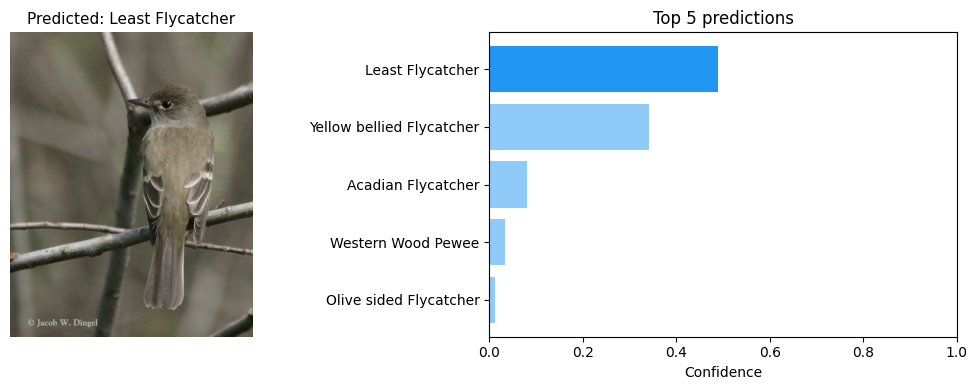

In [10]:
torch.save(model.state_dict(), 'bird_classifier_v2.pth')
print("Model saved ✅")

# ── Predict any image ───────────────────────────────────────────
def predict(image_path, top_k=5):
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze()
    top_probs, top_idxs = probs.topk(top_k)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f"Predicted: {CLASS_NAMES[top_idxs[0]].replace('_',' ')}", fontsize=11)

    colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(top_k)]
    labels = [CLASS_NAMES[i].replace('_', ' ') for i in top_idxs.cpu()]
    ax2.barh(labels[::-1], top_probs.cpu().numpy()[::-1], color=colors[::-1])
    ax2.set_xlabel('Confidence')
    ax2.set_title('Top 5 predictions')
    ax2.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

# Test on a sample
sample_cls = CLASS_NAMES[0]
sample_img = os.path.join(TEST_DIR, sample_cls,
             os.listdir(os.path.join(TEST_DIR, sample_cls))[0])
predict(sample_img)